In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim.lr_scheduler import OneCycleLR
from tqdm.auto import tqdm
import os
import pickle
import math # Transformer
from datetime import datetime

In [2]:
# Search GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla V100-SXM2-32GB


In [3]:
def normalize_quaternions(quaternion_features):
    """
    Normalise quaternion features to unit length: w²+x²+y²+z²=1
    """
    import numpy as np

    norms = np.linalg.norm(quaternion_features, axis=1, keepdims=True)

    norms[norms == 0] = 1.0

    normalized_quaternions = quaternion_features / norms

    if __debug__:
        verification_norms = np.linalg.norm(normalized_quaternions, axis=1)
        assert np.allclose(verification_norms, 1.0, atol=1e-6), \
            "Quaternion normalisation failed"

    return normalized_quaternions

In [4]:
# Dataset file.
file_path_Kabsch = '/srv/scratch/z5548879/VIVIAN_Dataset_V1/vive_vicon_comparison_data.csv'
#file_path_Kabsch = '/srv/scratch/z5548879/VIVIAN_Dataset_V2_with orientation/position_dataset.csv'

# Read Kabsch data (main dataset)
data_kabsch = pd.read_csv(file_path_Kabsch)

# Reorder data to ensure sorting by participant and timestamp
data_kabsch = data_kabsch.sort_values(['participant_id', 'time_stamp'] if 'participant_id' in data_kabsch.columns and 'time_stamp' in data_kabsch.columns 
                       else [data_kabsch.columns[0], data_kabsch.columns[4]])

data_kabsch_numpy = data_kabsch.to_numpy()

# Extract basic info from Kabsch data
participant_id = data_kabsch_numpy[:, 0]  
speed = data_kabsch_numpy[:, 1]           # 0.5 1.0 1.5 2.0 m/s
height = data_kabsch_numpy[:, 2]          # Tracker: 1, 2, 3
direction = data_kabsch_numpy[:, 3]       # XYZ

# Extract position data - separate by direction (VIVE as input, Vicon as target)
vicon_data = data_kabsch_numpy[:, 6]  # Vicon data (target)
vive_data = data_kabsch_numpy[:, 7]   # VIVE data (input)

# Extract XYZ directional position features (including tracker information)
def extract_xyz_features(position_data, participant_ids, speed_data, height_data, direction_data):
    """Extract XYZ position features for each participant, speed, and tracker"""
    unique_participants = np.unique(participant_ids)
    unique_speeds = np.unique(speed_data)
    unique_heights = np.unique(height_data)
    
    # Calculate total number of data points
    total_points = 0
    for participant in unique_participants:
        for speed_val in unique_speeds:
            for height_val in unique_heights:  # Add tracker loop
                mask = (participant_ids == participant) & (speed_data == speed_val) & (height_data == height_val)
                if np.any(mask):
                    x_mask = mask & (direction_data == 'X')
                    total_points += np.sum(x_mask)
    
    # Initialize feature matrix
    xyz_features = np.zeros((total_points, 3))
    xyz_spatial_magnitude = np.zeros(total_points)
    feature_participant_ids = []
    feature_speeds = []
    feature_heights = []  # Add heights list
    
    current_idx = 0
    
    for participant in unique_participants:
        for speed_val in unique_speeds:
            for height_val in unique_heights:  # Add tracker loop
                # Get data for current participant, speed, and tracker
                base_mask = (participant_ids == participant) & (speed_data == speed_val) & (height_data == height_val)
                
                if np.any(base_mask):
                    x_mask = base_mask & (direction_data == 'X')
                    y_mask = base_mask & (direction_data == 'Y')
                    z_mask = base_mask & (direction_data == 'Z')
                    
                    x_indices = np.where(x_mask)[0]
                    y_indices = np.where(y_mask)[0] 
                    z_indices = np.where(z_mask)[0]
                    
                    # Ensure XYZ data lengths are consistent
                    min_length = min(len(x_indices), len(y_indices), len(z_indices))
                    
                    if min_length > 0:
                        x_values = np.array(position_data[x_indices[:min_length]], dtype=float)
                        y_values = np.array(position_data[y_indices[:min_length]], dtype=float)
                        z_values = np.array(position_data[z_indices[:min_length]], dtype=float)
                        
                        # Store XYZ features
                        end_idx = current_idx + min_length
                        xyz_features[current_idx:end_idx, 0] = x_values
                        xyz_features[current_idx:end_idx, 1] = y_values
                        xyz_features[current_idx:end_idx, 2] = z_values
                        
                        # Calculate spatial magnitude
                        spatial_magnitude = np.sqrt(x_values**2 + y_values**2 + z_values**2)
                        xyz_spatial_magnitude[current_idx:end_idx] = spatial_magnitude
                        
                        # Record corresponding participant, speed, and tracker information
                        for _ in range(min_length):
                            feature_participant_ids.append(participant)
                            feature_speeds.append(speed_val)
                            feature_heights.append(height_val)  # Add tracker
                        
                        current_idx = end_idx
    
    # Truncate to actually used portion
    xyz_features = xyz_features[:current_idx]
    xyz_spatial_magnitude = xyz_spatial_magnitude[:current_idx]
    
    return (xyz_features, xyz_spatial_magnitude, 
            np.array(feature_participant_ids), 
            np.array(feature_speeds),
            np.array(feature_heights))  # Return heights

print("Extracting VIVE XYZ position features...")
vive_xyz, vive_spatial_mag, vive_participants, vive_speeds, vive_heights = extract_xyz_features(
    vive_data, participant_id, speed, height, direction)  # Add height parameter

print("Extracting Vicon XYZ position features...")
vicon_xyz, vicon_spatial_mag, vicon_participants, vicon_speeds, vicon_heights = extract_xyz_features(
    vicon_data, participant_id, speed, height, direction)  # Add height parameter

print("VIVE XYZ feature shape:", vive_xyz.shape)
print("VIVE spatial magnitude shape:", vive_spatial_mag.shape)
print("Vicon XYZ feature shape:", vicon_xyz.shape)
print("Vicon spatial magnitude shape:", vicon_spatial_mag.shape)

# Ensure data length alignment
min_length = min(len(vive_xyz), len(vicon_xyz))
print(f"Data alignment length: {min_length}")

# Truncate to same length
vive_xyz = vive_xyz[:min_length]
vive_spatial_mag = vive_spatial_mag[:min_length]
vicon_xyz = vicon_xyz[:min_length]
vicon_spatial_mag = vicon_spatial_mag[:min_length]
aligned_participants = vive_participants[:min_length]
aligned_speeds = vive_speeds[:min_length]
aligned_height = vive_heights[:min_length]  # Use heights returned from function

print(f"Tracker distribution after alignment: {np.unique(aligned_height, return_counts=True)}")

# Process categorical features
participant_encoder = LabelEncoder()
participant_encoded = participant_encoder.fit_transform(aligned_participants)
participant_normalised = participant_encoded / (len(np.unique(participant_encoded)) - 1)

# Standardize all numerical features
# NOTE: Scalers must NOT be fit on the full dataset here — that leaks
# validation-fold statistics into training. They are fit per-fold instead,
# inside the cross-validation loop, on the training split only.

# Combine all RAW features (standardisation is done per-fold)
additional_features = np.hstack([
    aligned_speeds.reshape(-1, 1),            # 1 feature: speed
    aligned_height.reshape(-1, 1),            # 1 feature: tracker position
    vive_spatial_mag.reshape(-1, 1),          # 1 feature: VIVE spatial magnitude
    vive_xyz
])

print("Final feature matrix shape:", additional_features.shape)

# Generate sequence data
seq_length = 200

def create_sequences_with_xyz_features(xyz_input, additional_feats, xyz_target, participant_ids, heights, seq_length=200):
    """Create sequence data with XYZ features, grouped by participant and tracker"""
    x_time, x_feat, y, seq_participant_ids, seq_heights = [], [], [], [], []
    
    unique_participants = np.unique(participant_ids)
    unique_heights = np.unique(heights)
    
    # Group by participant and tracker combination
    for participant in unique_participants:
        for height in unique_heights:
            # Filter by both participant and tracker
            mask = (participant_ids == participant) & (heights == height)
            indices = np.where(mask)[0]
            
            if len(indices) < seq_length + 1:
                continue
            
            # Create sequences for current participant-tracker combination
            for i in range(len(indices) - seq_length):
                # Critical modification: use indices array instead of direct indexing
                seq_indices = indices[i:i+seq_length]  # Get sequence indices
                target_idx = indices[i + seq_length]    # Target index
                
                x_time.append(xyz_input[seq_indices])        # Use sequence indices
                x_feat.append(additional_feats[target_idx])  # Additional features
                y.append(xyz_target[target_idx])             # XYZ target
                seq_participant_ids.append(participant_ids[target_idx])
                seq_heights.append(heights[target_idx])
    
    print(f"Total sequences generated: {len(x_time)}")
    
    return (np.array(x_time), np.array(x_feat), np.array(y), 
            np.array(seq_participant_ids), np.array(seq_heights))

print("Generating XYZ sequence data...")
# Use RAW arrays; sequences are scaled per-fold inside the CV loop.
X_time, X_feat, y, seq_participant_ids, seq_heights = create_sequences_with_xyz_features(
    vive_xyz, additional_features, vicon_xyz, 
    aligned_participants, aligned_height, seq_length
)

print("Final training data shape:")
print("X_time (VIVE XYZ time series):", X_time.shape)
print("X_feat (additional features):", X_feat.shape)
print("y (Vicon XYZ target):", y.shape)
print("Number of sequences:", len(seq_participant_ids))

# Check tracker distribution
unique_heights_in_seq, counts = np.unique(seq_heights, return_counts=True)
print("\nTracker distribution:")
for h, c in zip(unique_heights_in_seq, counts):
    print(f"  Tracker {int(h)}: {c} sequences")

Extracting VIVE XYZ position features...
Extracting Vicon XYZ position features...
VIVE XYZ feature shape: (600000, 3)
VIVE spatial magnitude shape: (600000,)
Vicon XYZ feature shape: (600000, 3)
Vicon spatial magnitude shape: (600000,)
Data alignment length: 600000
Tracker distribution after alignment: (array([1, 2, 3]), array([200000, 200000, 200000]))
Final feature matrix shape: (600000, 6)
Generating XYZ sequence data...
Total sequences generated: 594000
Final training data shape:
X_time (VIVE XYZ time series): (594000, 200, 3)
X_feat (additional features): (594000, 6)
y (Vicon XYZ target): (594000, 3)
Number of sequences: 594000

Tracker distribution:
  Tracker 1: 198000 sequences
  Tracker 2: 198000 sequences
  Tracker 3: 198000 sequences


In [5]:
class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-5, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()

In [6]:
class PositionalEncoding(nn.Module):
    """ Add Transformer location information"""
    def __init__(self, d_model, max_len=5000, batch_first=True):
        super(PositionalEncoding, self).__init__()
        self.batch_first = batch_first
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                           (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        if batch_first:
            # (1, max_len, d_model) for batch_first=True
            pe = pe.unsqueeze(0)
        else:
            # (max_len, 1, d_model) for batch_first=False
            pe = pe.unsqueeze(1)
            
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        if self.batch_first:
            # x shape: (batch_size, seq_len, d_model)
            seq_len = x.size(1)
            return x + self.pe[:, :seq_len, :]
        else:
            # x shape: (seq_len, batch_size, d_model)
            seq_len = x.size(0)
            return x + self.pe[:seq_len, :, :]

In [7]:
class TransformerBlock(nn.Module):
    """ Single Transformer block with Pre-LayerNorm architecture"""
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        
        self._init_weights()
        
    def _init_weights(self):
        """Initialize weights using Xavier uniform initialization"""
        nn.init.xavier_uniform_(self.linear1.weight)
        nn.init.xavier_uniform_(self.linear2.weight)
        nn.init.constant_(self.linear1.bias, 0)
        nn.init.constant_(self.linear2.bias, 0)
        
    def forward(self, src, src_mask=None, src_key_padding_mask=None, return_attention=False):
        # Pre-LayerNorm:
        # Self-attention
        norm_src = self.norm1(src)
        src2, attention_weights = self.self_attn(norm_src, norm_src, norm_src, 
                                               attn_mask=src_mask,
                                               key_padding_mask=src_key_padding_mask)
        src = src + self.dropout1(src2)
        
        # Feed forward
        norm_src = self.norm2(src)
        src2 = self.linear2(self.dropout(torch.relu(self.linear1(norm_src))))
        src = src + self.dropout2(src2)
        
        if return_attention:
            return src, attention_weights
        return src

In [8]:
class AdvancedTransformerModel(nn.Module):
    def __init__(self, seq_length, num_features=3, hidden_dim=128, dropout_rate=0.1,
                 nhead=8, num_transformer_layers=3, dim_feedforward=512):
        super(AdvancedTransformerModel, self).__init__()
        # dropout_rate 0.2-0.01

        # Ensure hidden_dim is divisible by nhead
        if hidden_dim % nhead != 0:
            hidden_dim = ((hidden_dim // nhead) + 1) * nhead
            print(f"Adjusted hidden_dim to {hidden_dim} to be compatible with multi-head attention")

        self.hidden_dim = hidden_dim
        self.seq_length = seq_length

        # Enhanced CNN feature extractor -- designed to capture peaks and troughs
        self.conv1 = nn.Sequential(
            nn.Conv1d(3, 64, kernel_size=3, padding=1),  # Increased channel count
            nn.GroupNorm(8, 64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),  # Extra convolution layer
            nn.GroupNorm(8, 64),
            nn.ReLU()
        )

        # Multi-scale convolution -- captures peaks and troughs at different frequencies
        self.conv_ms1 = nn.Conv1d(64, 32, kernel_size=3, padding=1)  # Short-term patterns
        self.conv_ms2 = nn.Conv1d(64, 32, kernel_size=5, padding=2)  # Mid-term patterns
        self.conv_ms3 = nn.Conv1d(64, 32, kernel_size=7, padding=3)  # Long-term patterns

        self.conv2 = nn.Sequential(
            nn.GroupNorm(12, 96),  # 32*3 = 96 from multi-scale
            nn.ReLU(),
            nn.Conv1d(96, 128, kernel_size=3, padding=1),
            nn.GroupNorm(16, 128),
            nn.ReLU()
        )

        # Gradient feature extractor -- captures sharp changes at peaks and troughs
        self.gradient_conv = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=3, padding=1),
            nn.GroupNorm(4, 32),
            nn.Tanh(),  # Tanh better captures gradient changes
            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.GroupNorm(4, 32),
            nn.Tanh()
        )

        self.dropout_cnn = nn.Dropout(dropout_rate)  # 0.1

        # Projection layer: maps CNN output dimension to Transformer input dimension
        self.cnn_projection = nn.Linear(160, hidden_dim)  # 128+32=160

        # Positional encoding -- using batch_first=True for consistency
        self.pos_encoder = PositionalEncoding(hidden_dim, max_len=seq_length, batch_first=True)

        # Transformer encoder layers
        self.transformer_layers = nn.ModuleList([
            TransformerBlock(hidden_dim, nhead, dim_feedforward, dropout_rate)  # Reduced dropout 0.7->0.05
            for _ in range(num_transformer_layers)
        ])

        # Global attention pooling layer (replaces the original simple attention mechanism)
        self.global_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=nhead,
            batch_first=True
        )

        # Learnable query vector for global pooling
        self.global_query = nn.Parameter(torch.randn(1, 1, hidden_dim))

        # Enhanced feature processing network
        self.feat_fc1 = nn.Sequential(
            nn.Linear(num_features, 64),  # Increased capacity
            nn.LayerNorm(64),
            nn.ReLU(),
        )

        self.feat_fc2 = nn.Sequential(
            nn.Linear(64, 128),  # Increased capacity
            nn.LayerNorm(128),
            nn.ReLU(),
        )

        # Improved residual connection
        self.feat_res = nn.Sequential(
            nn.Linear(num_features, 128),  # Matches feat_fc2 output
            nn.LayerNorm(128)
        )

        # Feature fusion layer
        self.feature_fusion = nn.Sequential(
            nn.Linear(hidden_dim + 128, hidden_dim * 2),  # Increased capacity
            nn.LayerNorm(hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        # Final classification head -- enhanced nonlinear transformation capacity
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 3)
        )

        # Weight initialisation
        self._init_weights()

    def _init_weights(self):
        """Xavier initialisation"""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Conv1d):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x_time, x_feat, return_attention=False):
        batch_size = x_time.size(0)

        # Time-series CNN feature extraction
        x_time_input = x_time.permute(0, 2, 1)  # [batch, 1, seq_len]

        # Primary feature extraction
        x = self.conv1(x_time_input)

        # Multi-scale feature extraction
        x_ms1 = self.conv_ms1(x)
        x_ms2 = self.conv_ms2(x)
        x_ms3 = self.conv_ms3(x)
        x_multi_scale = torch.cat([x_ms1, x_ms2, x_ms3], dim=1)

        x = self.conv2(x_multi_scale)

        # Gradient feature extraction -- compute first-order differences to capture rate of change
        x_grad_input = torch.diff(x_time_input, dim=2, prepend=x_time_input[:, :, :1])
        x_grad = self.gradient_conv(x_grad_input)

        # Merge primary features and gradient features
        x_combined = torch.cat([x, x_grad], dim=1)  # [batch, 160, seq_len]
        x_combined = self.dropout_cnn(x_combined)

        # Convert to Transformer input format
        x_combined = x_combined.permute(0, 2, 1)       # [batch, seq_len, 160]
        x_combined = self.cnn_projection(x_combined)    # [batch, seq_len, hidden_dim]

        # Apply positional encoding
        x_combined = self.pos_encoder(x_combined)

        # Pass through Transformer layers
        attention_weights_list = []
        for transformer_layer in self.transformer_layers:
            if return_attention:
                x_combined, attention_weights = transformer_layer(x_combined, return_attention=True)
                attention_weights_list.append(attention_weights)
            else:
                x_combined = transformer_layer(x_combined, return_attention=False)

        # Global attention pooling
        global_query = self.global_query.expand(batch_size, -1, -1)
        context, global_attention_weights = self.global_attention(
            global_query, x_combined, x_combined
        )
        context = context.squeeze(1)  # [batch, hidden_dim]

        # Feature processing
        feat_out = self.feat_fc1(x_feat)
        feat_out = self.feat_fc2(feat_out)
        feat_residual = self.feat_res(x_feat)
        feat_out = feat_out + feat_residual  # Residual connection

        # Feature fusion
        combined = torch.cat([context, feat_out], dim=1)
        fused_features = self.feature_fusion(combined)

        # Final prediction
        output = self.classifier(fused_features)

        if return_attention:
            return output, {
                'transformer_attention': attention_weights_list,
                'global_attention': global_attention_weights
            }
        else:
            return output


# Initialise model, loss, optimiser, and scheduler
model = AdvancedTransformerModel(seq_length, num_features=3).to(device)
print(model)

AdvancedTransformerModel(
  (conv1): Sequential(
    (0): Conv1d(3, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): GroupNorm(8, 64, eps=1e-05, affine=True)
    (5): ReLU()
  )
  (conv_ms1): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv_ms2): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv_ms3): Conv1d(64, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Sequential(
    (0): GroupNorm(12, 96, eps=1e-05, affine=True)
    (1): ReLU()
    (2): Conv1d(96, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): GroupNorm(16, 128, eps=1e-05, affine=True)
    (4): ReLU()
  )
  (gradient_conv): Sequential(
    (0): Conv1d(3, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): GroupNorm(4, 32, eps=1e-05, affine=True)
    (2): Tanh()
    (3): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padd

In [9]:
def train_model(model, train_loader, val_loader, criterion, optimiser, scheduler, epochs=50, patience=8):
    best_val_loss = float('inf')
    best_model = None
    history = {'train_loss': [], 'val_loss': [],
              'train_loss_eval_mode':[]
              }

    early_stopping = EarlyStopping(patience=patience, restore_best_weights=True)
    
    # Gradient accumulation settings
    accum_steps = 4  # Update weights every 4 batches
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("---" * 30)  # Progress bar separator
        
        # Training phase
        model.train()
        train_predictions = []
        train_actuals = []
        train_losses = []
        
        optimiser.zero_grad()  # Zero gradients at start of epoch
        
        # Create progress bar for training
        train_pbar = tqdm(train_loader, desc="Training", leave=True)
        
        for i, (batch_X_time, batch_X_feat, batch_y) in enumerate(train_pbar):
            # Move data to device
            batch_X_time = batch_X_time.to(device)
            batch_X_feat = batch_X_feat.to(device)
            batch_y = batch_y.to(device)
            
            # Forward pass
            output = model(batch_X_time, batch_X_feat)
            
            # Calculate original loss for logging and statistics
            original_loss = criterion(output, batch_y)
            
            # Record original loss for statistics
            train_losses.append(original_loss.item())
            
            # Scale loss for gradient accumulation
            scaled_loss = original_loss / accum_steps
            scaled_loss.backward()
            
            # Collect predictions and actuals for RMSE calculation (detach from graph)
            train_predictions.append(output.detach().cpu().numpy())
            train_actuals.append(batch_y.detach().cpu().numpy())
            
            # Update weights every accum_steps batches
            if (i + 1) % accum_steps == 0 or (i + 1) == len(train_loader):
                # Gradient clipping to prevent exploding gradients
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                optimiser.step()
                optimiser.zero_grad()
                
                # Clean up GPU memory
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
            
            # Update progress bar with original loss
            train_pbar.set_postfix({"batch_loss": f"{original_loss.item():.4f}"})
            
            # Free up memory
            del batch_X_time, batch_X_feat, batch_y, output, original_loss, scaled_loss
        
        # Calculate training loss
        train_loss = np.mean(train_losses)
        history['train_loss'].append(train_loss)
        
        # Validation phase
        model.eval()
        val_predictions = []
        val_actuals = []     
        train_eval_losses = []
        
        #with torch.no_grad():
        #   train_eval_pbar = tqdm(train_loader, desc="Train Eval", leave=True)
        #    for batch_X_time, batch_X_feat, batch_y in train_eval_pbar:
        #        batch_X_time = batch_X_time.to(device)
        #        batch_X_feat = batch_X_feat.to(device)
        #        batch_y = batch_y.to(device)
        #        
        #        output = model(batch_X_time, batch_X_feat)
        #        batch_loss = criterion(output, batch_y).item()
        #        train_eval_losses.append(batch_loss)
        #        
        #        del batch_X_time, batch_X_feat, batch_y, output
        
        #train_eval_loss = np.mean(train_eval_losses)
        #history['train_loss_eval_mode'].append(train_eval_loss)

        val_losses = []
        # Create progress bar for validation
        val_pbar = tqdm(val_loader, desc="Validation", leave=True)
        
        with torch.no_grad():
            for batch_X_time, batch_X_feat, batch_y in val_pbar:
                # Move data to device
                batch_X_time = batch_X_time.to(device)
                batch_X_feat = batch_X_feat.to(device)
                batch_y = batch_y.to(device)
                
                output = model(batch_X_time, batch_X_feat)
                
                # Collect predictions and actuals for RMSE calculation
                val_predictions.append(output.cpu().numpy())
                val_actuals.append(batch_y.cpu().numpy())
                
                # Calculate loss for progress bar
                batch_loss = criterion(output, batch_y).item()
                val_losses.append(batch_loss)
                val_pbar.set_postfix({"batch_loss": f"{batch_loss:.4f}"})
                
                # Free up memory
                del batch_X_time, batch_X_feat, batch_y, output
        
        # Calculate validation loss
        val_loss = np.mean(val_losses)
        history['val_loss'].append(val_loss)
        
        # Update learning rate
        scheduler.step(val_loss)
        # print(f"Epoch {epoch+1}/{epochs} completed - Train Loss: {train_loss:.4f}, Train Eval: {train_eval_loss:.4f}, Val Loss: {val_loss:.4f}")
        print(f"Epoch {epoch+1}/{epochs} completed - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        for param_group in optimiser.param_groups:
            print(f"Current LR: {param_group['lr']}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict().copy()
            print(f"New best model saved with Val Loss: {val_loss:.4f}")
            
        if early_stopping(val_loss, model):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
        
        # Clean up GPU memory at end of epoch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # Load best model
    model.load_state_dict(best_model)
    return model, history

In [10]:
# Function to evaluate the model
def evaluate_model(model, val_loader, criterion):
    model.eval()
    #val_loss = 0.0
    predictions = []
    actuals = []
    val_losses = []
    
    with torch.no_grad():
        for batch_X_time, batch_X_feat, batch_y in val_loader:
            batch_X_time = batch_X_time.to(device)
            batch_X_feat = batch_X_feat.to(device)
            batch_y = batch_y.to(device)
            
            #output = model(batch_X_time, batch_X_feat)
            #output, attention_info = model(batch_X_time, batch_X_feat, return_attention=True)
            if hasattr(model, 'return_attention'):
                 output, attention_info = model(batch_X_time, batch_X_feat, return_attention=True)
            else:
                 output = model(batch_X_time, batch_X_feat)
                
            loss = criterion(output, batch_y)
            val_losses.append(loss.item())
            
            # Collect predictions and actuals for later analysis
            predictions.append(output.cpu().numpy())
            actuals.append(batch_y.cpu().numpy())
            
            # Free memory
            del batch_X_time, batch_X_feat, batch_y, output, loss
    
    # Convert lists to arrays
    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)
    
    # Calculate RMSE
    # avg_val_loss = val_losses / len(val_loader)
    avg_val_loss = np.mean(val_losses)
    
    return avg_val_loss, predictions, actuals

In [11]:
# Participant-based K-fold cross-validation
print("Starting Participant-based K-fold Cross Validation...")
# Get unique participant IDs
unique_participants = np.unique(seq_participant_ids)
print(f"Available participants: {unique_participants}")

Starting Participant-based K-fold Cross Validation...
Available participants: ['HW3-001' 'HW3-002' 'HW3-003' 'HW3-004' 'HW3-005' 'HW3-006' 'HW3-007'
 'HW3-008' 'HW3-009' 'HW3-010']


In [12]:
# Participant-based K-Fold Cross Validation
num_folds = len(unique_participants)  # 10-fold (each participant as validation set once)
fold_rmse_scores = []
best_models = []
all_fold_scalers = []
all_histories = []
batch_size = 64

# Loop through each participant as validation set
for fold, val_participant in enumerate(unique_participants):
    print(f"\nFold {fold+1}/{num_folds} - Validation Participant: {val_participant}")
    print("-" * 60)
    
    # Create training and validation indices
    val_indices = np.where(seq_participant_ids == val_participant)[0]
    train_indices = np.where(seq_participant_ids != val_participant)[0]
    
    print(f"Training samples: {len(train_indices)}, Validation samples: {len(val_indices)}")

    train_indices_sparse = train_indices[::10]
    val_indices_sparse = val_indices[::5]
    
    # Create training and validation sets (RAW values)
    X_time_train, X_time_val = X_time[train_indices_sparse], X_time[val_indices_sparse]
    X_feat_train, X_feat_val = X_feat[train_indices_sparse], X_feat[val_indices_sparse]
    y_train, y_val = y[train_indices_sparse], y[val_indices_sparse]
    
    # --- Per-fold standardisation: fit on TRAIN ONLY to avoid data leakage ---
    fold_scalers = {}
    n_tr, sl, ch = X_time_train.shape
    
    # X_time (N, seq_length, 3): scale each XYZ channel
    fold_scalers['vive_xyz'] = StandardScaler()
    X_time_train = fold_scalers['vive_xyz'].fit_transform(
        X_time_train.reshape(-1, ch)).reshape(n_tr, sl, ch)
    X_time_val = fold_scalers['vive_xyz'].transform(
        X_time_val.reshape(-1, ch)).reshape(X_time_val.shape[0], sl, ch)
    
    # X_feat (N, num_features): speed / height / VIVE spatial magnitude
    fold_scalers['feat'] = StandardScaler()
    X_feat_train = fold_scalers['feat'].fit_transform(X_feat_train)
    X_feat_val = fold_scalers['feat'].transform(X_feat_val)
    
    # y (N, 3): Vicon XYZ target
    fold_scalers['vicon_xyz'] = StandardScaler()
    y_train = fold_scalers['vicon_xyz'].fit_transform(y_train)
    y_val = fold_scalers['vicon_xyz'].transform(y_val)
    
    all_fold_scalers.append(fold_scalers)
    # ------------------------------------------------------------------------
    
    # Create data loaders
    train_dataset = TensorDataset(
        torch.tensor(X_time_train, dtype=torch.float32),
        torch.tensor(X_feat_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )
    val_dataset = TensorDataset(
        torch.tensor(X_time_val, dtype=torch.float32),
        torch.tensor(X_feat_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size*4, shuffle=False, pin_memory=True)
    
    # Initialize model
    model = AdvancedTransformerModel(seq_length, num_features=X_feat.shape[1]).to(device)
    
    print(f"\nModel Structure for Fold {fold+1}:")
    print(model)
    
    # Combined MSE and L1 loss
    mse_loss = nn.MSELoss()
    l1_loss = nn.L1Loss()
    # criterion = lambda output, target: mse_loss(output, target) + 0.1 * l1_loss(output, target)
    criterion = nn.HuberLoss(delta=1.0)
    
    # Initialize optimizer and learning rate scheduler
    optimiser = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
    scheduler = ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=3)
    #scheduler = OneCycleLR(optimiser, max_lr=0.001, epochs=50, steps_per_epoch=len(train_loader), pct_start=0.1,      # 前10%的步数做warmup
    #    anneal_strategy='cos')
    
    # Train model with early stopping
    model, history = train_model(
        model, 
        train_loader, 
        val_loader, 
        criterion, 
        optimiser, 
        scheduler, 
        epochs=50, 
        patience=8
    )
    
    # Evaluate model on validation set
    fold_rmse, predictions, actuals = evaluate_model(model, val_loader, criterion)
    fold_rmse_scores.append(fold_rmse)
    
    print(f"Fold {fold+1} ({val_participant}) Loss: {fold_rmse:.4f}")
    
    # Save model state and training history
    best_models.append(model.state_dict().copy())
    all_histories.append(history)
    
    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Print overall cross-validation results
print("\nParticipant-based K-fold Cross Validation Results:")
print("-" * 60)
for fold, (participant, rmse) in enumerate(zip(unique_participants, fold_rmse_scores)):
    print(f"Fold {fold+1} ({participant}): Loss = {rmse:.4f}")
print(f"Average Loss: {np.mean(fold_rmse_scores):.4f}")
print(f"Standard Deviation: {np.std(fold_rmse_scores):.4f}")

# Select best model based on lowest validation loss
best_fold_idx = np.argmin(fold_rmse_scores)
best_participant = unique_participants[best_fold_idx]
print(f"\nBest model is from Fold {best_fold_idx+1} (validation on {best_participant}) with Loss: {fold_rmse_scores[best_fold_idx]:.4f}")


Fold 1/10 - Validation Participant: HW3-001
------------------------------------------------------------
Training samples: 534600, Validation samples: 59400

Model Structure for Fold 1:
AdvancedTransformerModel(
  (conv1): Sequential(
    (0): Conv1d(3, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): GroupNorm(8, 64, eps=1e-05, affine=True)
    (5): ReLU()
  )
  (conv_ms1): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv_ms2): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv_ms3): Conv1d(64, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Sequential(
    (0): GroupNorm(12, 96, eps=1e-05, affine=True)
    (1): ReLU()
    (2): Conv1d(96, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): GroupNorm(16, 128, eps=1e-05, affine=True)
    (4): ReLU()
  )
  (gradient_conv): Sequential(
    (0

Training:   0%|          | 0/836 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1/50 completed - Train Loss: 0.0208, Val Loss: 0.0052
Current LR: 0.0001
New best model saved with Val Loss: 0.0052

Epoch 2/50
------------------------------------------------------------------------------------------


Training:   0%|          | 0/836 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 20/50 completed - Train Loss: 0.0003, Val Loss: 0.0008
Current LR: 0.0001

Epoch 21/50
------------------------------------------------------------------------------------------


Training:   0%|          | 0/836 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 21/50 completed - Train Loss: 0.0003, Val Loss: 0.0008
Current LR: 5e-05
Early stopping triggered at epoch 21
Fold 10 (HW3-010) Loss: 0.0008

Participant-based K-fold Cross Validation Results:
------------------------------------------------------------
Fold 1 (HW3-001): Loss = 0.0013
Fold 2 (HW3-002): Loss = 0.0008
Fold 3 (HW3-003): Loss = 0.0004
Fold 4 (HW3-004): Loss = 0.0006
Fold 5 (HW3-005): Loss = 0.0005
Fold 6 (HW3-006): Loss = 0.0003
Fold 7 (HW3-007): Loss = 0.0004
Fold 8 (HW3-008): Loss = 0.0006
Fold 9 (HW3-009): Loss = 0.0004
Fold 10 (HW3-010): Loss = 0.0008
Average Loss: 0.0006
Standard Deviation: 0.0003

Best model is from Fold 6 (validation on HW3-006) with Loss: 0.0003


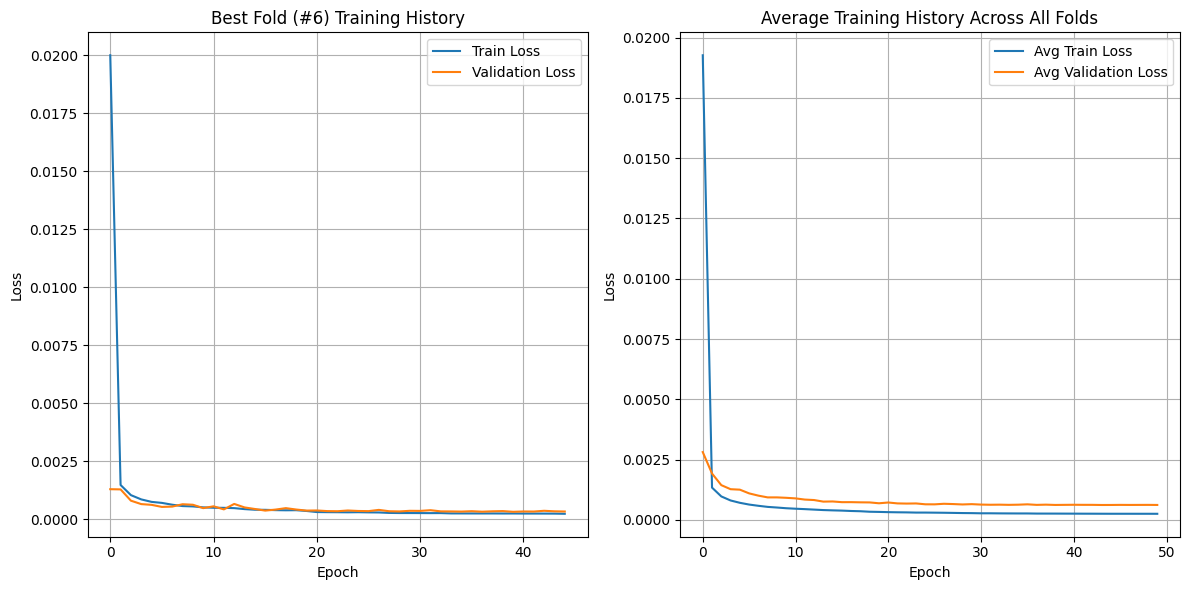

Model Performance Comparison:
Original VIVE vs Vicon:
  RMSE: 9.0607
  MAE:  4.9966

Ensemble Model vs Vicon:
  RMSE: 4.8859
  MAE:  3.0813

Improvement:
  RMSE: +46.08% (Better)
  MAE:  +38.33% (Better)


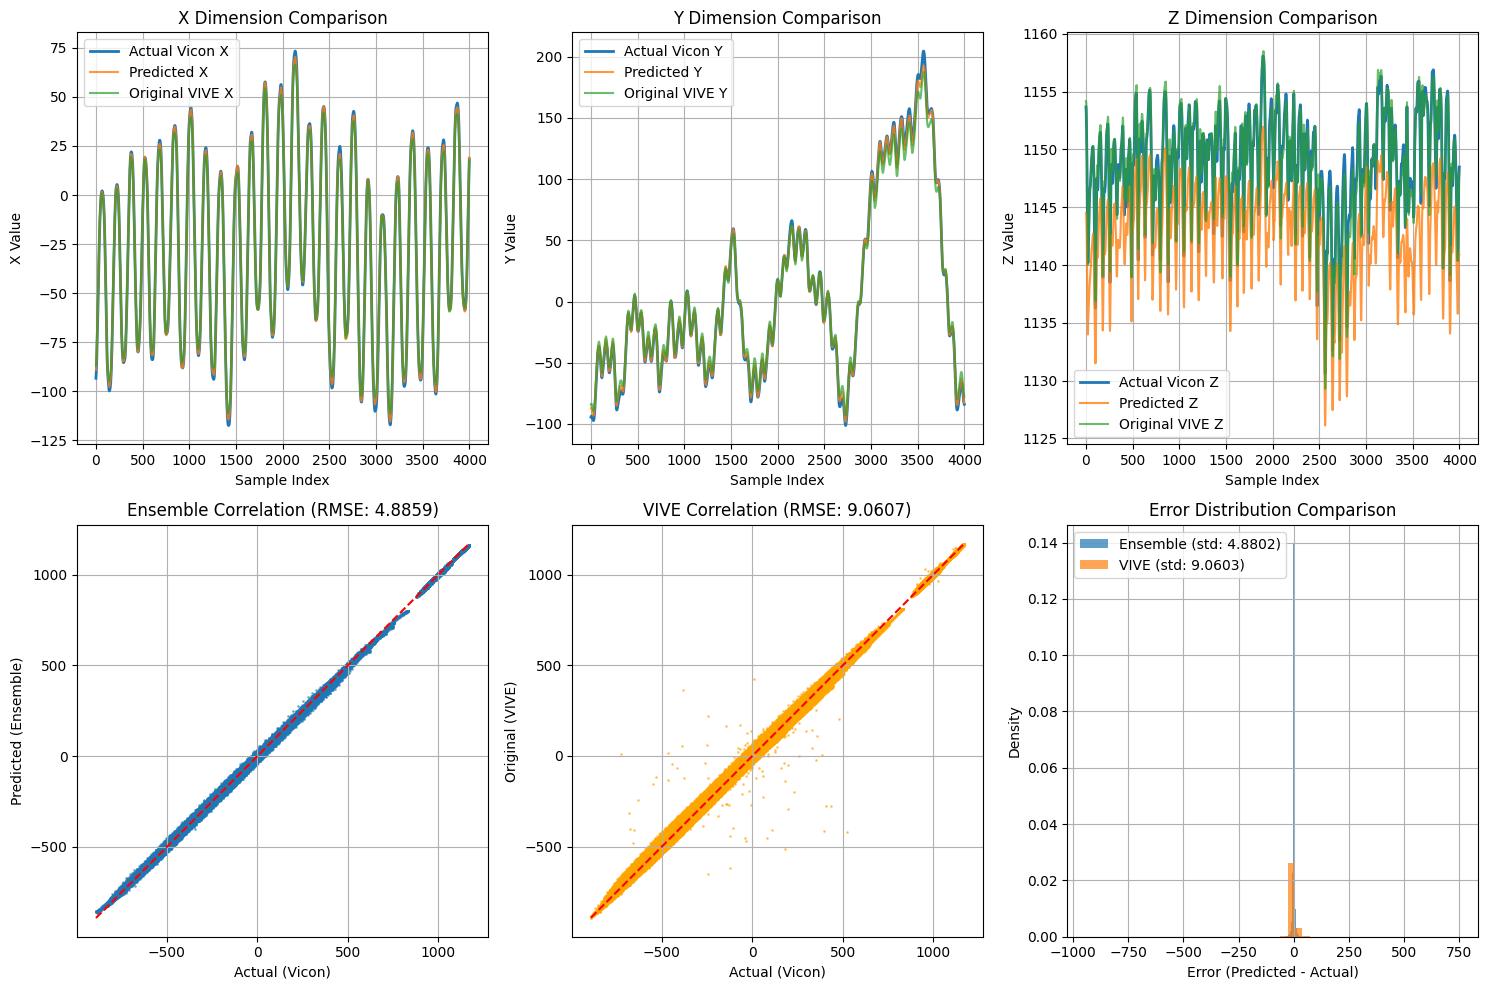


Detailed Error Statistics:
Ensemble Model Errors:
  Mean Error: 0.2354
  Std Error:  4.8802
  Min Error:  -57.2796
  Max Error:  53.7933

Original VIVE Errors:
  Mean Error: 0.0888
  Std Error:  9.0603
  Min Error:  -941.5429
  Max Error:  750.3173

Per-Dimension RMSE:
X Dimension:
  VIVE RMSE:     3.1548
  Ensemble RMSE: 2.2708
  Improvement:   +28.02%
Y Dimension:
  VIVE RMSE:     14.7388
  Ensemble RMSE: 7.4246
  Improvement:   +49.63%
Z Dimension:
  VIVE RMSE:     4.3709
  Ensemble RMSE: 3.3666
  Improvement:   +22.98%
Best model saved to 'best_vive_to_vicon_model.pth'


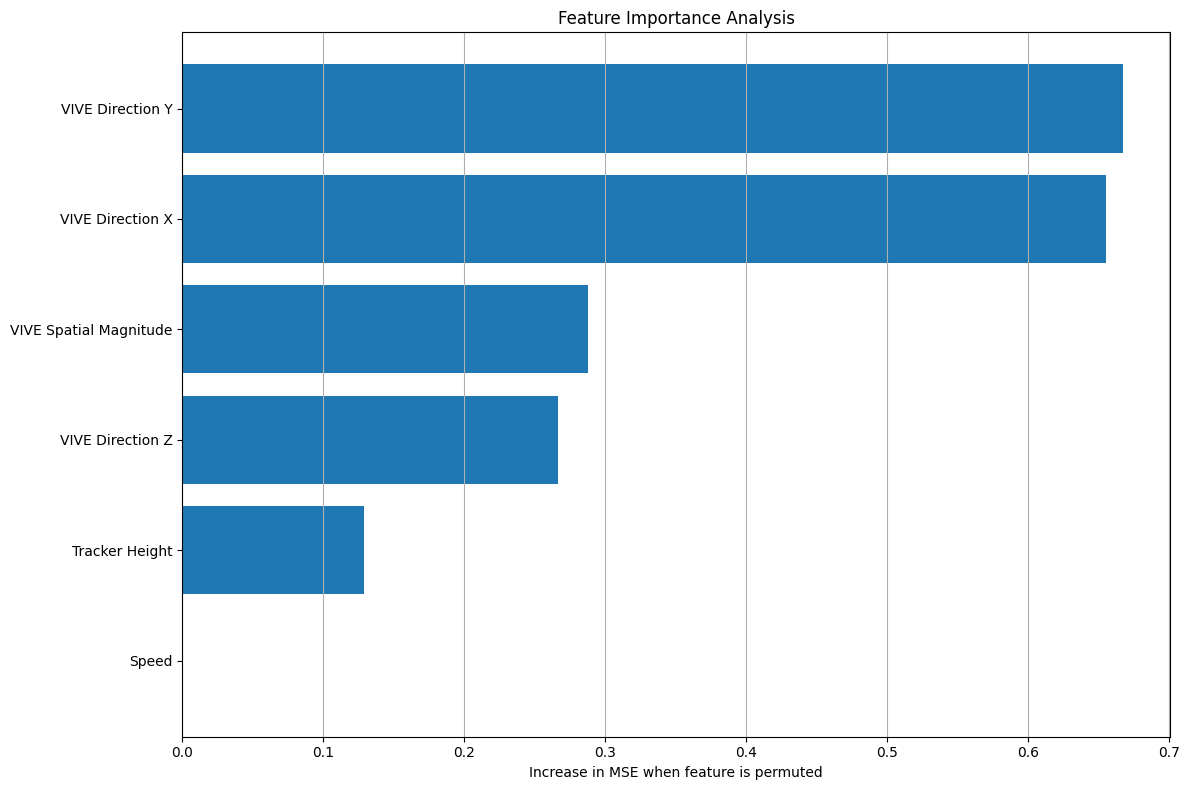

Feature importance analysis complete!
Ensemble model has been saved to 'feet_ensemble_models_LOPO.pkl'


In [15]:
# Initialise the final model with the best weights
final_model = AdvancedTransformerModel(seq_length, num_features=X_feat.shape[1]).to(device)
final_model.load_state_dict(best_models[best_fold_idx])

# Plot training history for the best fold
best_history = all_histories[best_fold_idx]
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(best_history['train_loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Best Fold (#{best_fold_idx+1}) Training History')
plt.legend()
plt.grid(True)

# Plot average training history across all folds
plt.subplot(1, 2, 2)
max_epochs = max(len(h['train_loss']) for h in all_histories)
padded_train_losses = []
padded_val_losses = []

for h in all_histories:
    train_loss = h['train_loss'] + [h['train_loss'][-1]] * (max_epochs - len(h['train_loss']))
    val_loss = h['val_loss'] + [h['val_loss'][-1]] * (max_epochs - len(h['val_loss']))
    
    padded_train_losses.append(train_loss)
    padded_val_losses.append(val_loss)

avg_train_loss = np.mean(padded_train_losses, axis=0)
avg_val_loss = np.mean(padded_val_losses, axis=0)

plt.plot(avg_train_loss, label='Avg Train Loss')
plt.plot(avg_val_loss, label='Avg Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Average Training History Across All Folds')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Ensemble prediction function (using all trained models)
# X_time_test / X_feat_test are RAW; each model is scaled with its own fold scaler,
# and predictions are inverse-transformed to original units before averaging.
def ensemble_predict(models, fold_scalers, X_time_test, X_feat_test, batch_size=64):
    predictions = []
    
    for model_state, scl in zip(models, fold_scalers):
        # Scale inputs with this fold's scaler
        n, sl, ch = X_time_test.shape
        X_time_s = scl['vive_xyz'].transform(
            X_time_test.reshape(-1, ch)).reshape(n, sl, ch)
        X_feat_s = scl['feat'].transform(X_feat_test)
        
        test_dataset = TensorDataset(
            torch.tensor(X_time_s, dtype=torch.float32),
            torch.tensor(X_feat_s, dtype=torch.float32)
        )
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        model = AdvancedTransformerModel(seq_length, num_features=X_feat.shape[1]).to(device)
        model.load_state_dict(model_state)
        model.eval()
        
        fold_preds = []
        with torch.no_grad():
            for batch_X_time, batch_X_feat in test_loader:
                batch_X_time = batch_X_time.to(device)
                batch_X_feat = batch_X_feat.to(device)
                
                output = model(batch_X_time, batch_X_feat)
                fold_preds.append(output.cpu().numpy())
                
                del batch_X_time, batch_X_feat, output
        
        # Concatenate predictions and inverse-transform to original units
        fold_preds = np.vstack(fold_preds)
        fold_preds = scl['vicon_xyz'].inverse_transform(fold_preds)
        predictions.append(fold_preds)
    
    # Average predictions from all models (in original units)
    ensemble_predictions = np.mean(predictions, axis=0)
    
    return ensemble_predictions

def evaluate_ensemble(models, fold_scalers, X_time, X_feat, y, batch_size=64):
    # Get ensemble predictions (already in original units)
    predictions = ensemble_predict(models, fold_scalers, X_time, X_feat, batch_size)
    
    # X_time, y are RAW (already in original units) — no inverse transform needed
    vive_original = X_time[:, -1]   # last VIVE timestep, shape (samples, 3)
    y_original = y
    
    # Calculate metrics for Ensemble vs Vicon
    ensemble_mse = np.mean((predictions - y_original) ** 2)
    ensemble_rmse = np.sqrt(ensemble_mse)
    ensemble_mae = np.mean(np.abs(predictions - y_original))
    
    # Calculate metrics for Original VIVE vs Vicon
    vive_mse = np.mean((vive_original - y_original) ** 2)
    vive_rmse = np.sqrt(vive_mse)
    vive_mae = np.mean(np.abs(vive_original - y_original))
    
    # Calculate improvement
    rmse_improvement = ((vive_rmse - ensemble_rmse) / vive_rmse) * 100
    mae_improvement = ((vive_mae - ensemble_mae) / vive_mae) * 100
    
    print(f"Model Performance Comparison:")
    print(f"{'='*50}")
    print(f"Original VIVE vs Vicon:")
    print(f"  RMSE: {vive_rmse:.4f}")
    print(f"  MAE:  {vive_mae:.4f}")
    print(f"")
    print(f"Ensemble Model vs Vicon:")
    print(f"  RMSE: {ensemble_rmse:.4f}")
    print(f"  MAE:  {ensemble_mae:.4f}")
    print(f"")
    print(f"Improvement:")
    print(f"  RMSE: {rmse_improvement:+.2f}% {'(Better)' if rmse_improvement > 0 else '(Worse)'}")
    print(f"  MAE:  {mae_improvement:+.2f}% {'(Better)' if mae_improvement > 0 else '(Worse)'}")
    
    # Visualize predictions vs actual
    plt.figure(figsize=(15, 10))
    
    # Plot a sample of the data (first 4000 points)
    sample_size = min(4000, len(predictions))
    
    # Time series comparison - show each XYZ dimension
    for i, dim in enumerate(['X', 'Y', 'Z']):
        plt.subplot(2, 3, i+1)
        plt.plot(y_original[:sample_size, i], label=f'Actual Vicon {dim}', linewidth=2)
        plt.plot(predictions[:sample_size, i], label=f'Predicted {dim}', alpha=0.8)
        plt.plot(vive_original[:sample_size, i], label=f'Original VIVE {dim}', alpha=0.7)
        plt.xlabel('Sample Index')
        plt.ylabel(f'{dim} Value')
        plt.title(f'{dim} Dimension Comparison')
        plt.legend()
        plt.grid(True)
    
    # Overall correlation plot for Ensemble
    plt.subplot(2, 3, 4)
    plt.scatter(y_original.flatten(), predictions.flatten(), alpha=0.5, s=1)
    plt.plot([y_original.min(), y_original.max()], [y_original.min(), y_original.max()], 'r--')
    plt.xlabel('Actual (Vicon)')
    plt.ylabel('Predicted (Ensemble)')
    plt.title(f'Ensemble Correlation (RMSE: {ensemble_rmse:.4f})')
    plt.grid(True)
    
    # Overall correlation plot for Original VIVE
    plt.subplot(2, 3, 5)
    plt.scatter(y_original.flatten(), vive_original.flatten(), alpha=0.5, s=1, color='orange')
    plt.plot([y_original.min(), y_original.max()], [y_original.min(), y_original.max()], 'r--')
    plt.xlabel('Actual (Vicon)')
    plt.ylabel('Original (VIVE)')
    plt.title(f'VIVE Correlation (RMSE: {vive_rmse:.4f})')
    plt.grid(True)
    
    # Error distribution comparison
    plt.subplot(2, 3, 6)
    ensemble_errors = predictions.flatten() - y_original.flatten()
    vive_errors = vive_original.flatten() - y_original.flatten()
    
    plt.hist(ensemble_errors, bins=50, alpha=0.7, label=f'Ensemble (std: {np.std(ensemble_errors):.4f})', density=True)
    plt.hist(vive_errors, bins=50, alpha=0.7, label=f'VIVE (std: {np.std(vive_errors):.4f})', density=True)
    plt.xlabel('Error (Predicted - Actual)')
    plt.ylabel('Density')
    plt.title('Error Distribution Comparison')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print(f"\nDetailed Error Statistics:")
    print(f"{'='*50}")
    print(f"Ensemble Model Errors:")
    print(f"  Mean Error: {np.mean(ensemble_errors):.4f}")
    print(f"  Std Error:  {np.std(ensemble_errors):.4f}")
    print(f"  Min Error:  {np.min(ensemble_errors):.4f}")
    print(f"  Max Error:  {np.max(ensemble_errors):.4f}")
    print(f"")
    print(f"Original VIVE Errors:")
    print(f"  Mean Error: {np.mean(vive_errors):.4f}")
    print(f"  Std Error:  {np.std(vive_errors):.4f}")
    print(f"  Min Error:  {np.min(vive_errors):.4f}")
    print(f"  Max Error:  {np.max(vive_errors):.4f}")
    
    # Print per-dimension statistics
    print(f"\nPer-Dimension RMSE:")
    print(f"{'='*30}")
    for i, dim in enumerate(['X', 'Y', 'Z']):
        ensemble_rmse_dim = np.sqrt(np.mean((predictions[:, i] - y_original[:, i]) ** 2))
        vive_rmse_dim = np.sqrt(np.mean((vive_original[:, i] - y_original[:, i]) ** 2))
        improvement_dim = ((vive_rmse_dim - ensemble_rmse_dim) / vive_rmse_dim) * 100
        
        print(f"{dim} Dimension:")
        print(f"  VIVE RMSE:     {vive_rmse_dim:.4f}")
        print(f"  Ensemble RMSE: {ensemble_rmse_dim:.4f}")
        print(f"  Improvement:   {improvement_dim:+.2f}%")
    
    return predictions, y_original, vive_original

# Evaluate the ensemble on the entire dataset
predictions, actuals, vive_original = evaluate_ensemble(best_models, all_fold_scalers, X_time, X_feat, y)

# Save the best model
torch.save(final_model.state_dict(), 'best_vive_to_vicon_model.pth')
print("Best model saved to 'best_vive_to_vicon_model.pth'")

# Feature importance analysis
def analyze_feature_importance(model, fold_scaler, X_time, X_feat, y, feature_names):
    # Scale RAW inputs/target with this model's fold scaler
    n, sl, ch = X_time.shape
    X_time = fold_scaler['vive_xyz'].transform(X_time.reshape(-1, ch)).reshape(n, sl, ch)
    X_feat = fold_scaler['feat'].transform(X_feat)
    y = fold_scaler['vicon_xyz'].transform(y)
    
    # Base performance
    model.eval()
    base_preds = []
    
    # Create dataset
    dataset = TensorDataset(
        torch.tensor(X_time, dtype=torch.float32),
        torch.tensor(X_feat, dtype=torch.float32)
    )
    data_loader = DataLoader(dataset, batch_size=64, shuffle=False)
    
    with torch.no_grad():
        for batch_X_time, batch_X_feat in data_loader:
            batch_X_time = batch_X_time.to(device)
            batch_X_feat = batch_X_feat.to(device)
            
            output = model(batch_X_time, batch_X_feat)
            base_preds.append(output.cpu().numpy())
    
    base_preds = np.vstack(base_preds)
    base_mse = np.mean((base_preds - y) ** 2)  # Updated: y is now 3D (samples, 3)
    
    # Permutation importance
    importance_scores = []
    
    for i in range(X_feat.shape[1]):
        # Create a copy and permute one feature
        X_feat_permuted = X_feat.copy()
        X_feat_permuted[:, i] = np.random.permutation(X_feat_permuted[:, i])
        
        # Predict with permuted feature
        perm_preds = []
        
        dataset_perm = TensorDataset(
            torch.tensor(X_time, dtype=torch.float32),
            torch.tensor(X_feat_permuted, dtype=torch.float32)
        )
        loader_perm = DataLoader(dataset_perm, batch_size=64, shuffle=False)
        
        with torch.no_grad():
            for batch_X_time, batch_X_feat in loader_perm:
                batch_X_time = batch_X_time.to(device)
                batch_X_feat = batch_X_feat.to(device)
                
                output = model(batch_X_time, batch_X_feat)
                perm_preds.append(output.cpu().numpy())
        
        perm_preds = np.vstack(perm_preds)
        perm_mse = np.mean((perm_preds - y) ** 2)  # Updated: y is now 3D (samples, 3)
        
        # Importance is the increase in error
        importance = perm_mse - base_mse
        importance_scores.append(importance)
    
    # Visualise feature importance
    plt.figure(figsize=(12, 8))
    sorted_idx = np.argsort(importance_scores)
    plt.barh(range(len(feature_names)), [importance_scores[i] for i in sorted_idx])
    plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx])
    plt.xlabel('Increase in MSE when feature is permuted')
    plt.title('Feature Importance Analysis')
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()
    
    return importance_scores

# Define feature names for visualization (updated to match new 7 features)
feature_names = [
    #'Participant ID', 
    'Speed',
    'Tracker Height',
    'VIVE Spatial Magnitude',
    'VIVE Direction X',
    'VIVE Direction Y',
    'VIVE Direction Z',
]

# Verify feature count matches
assert len(feature_names) == X_feat.shape[1], f"Feature names count ({len(feature_names)}) doesn't match actual features ({X_feat.shape[1]})"

# Analyze feature importance
importance_scores = analyze_feature_importance(
    final_model, all_fold_scalers[best_fold_idx], X_time, X_feat, y, feature_names)
print("Feature importance analysis complete!")

# Function to save ensemble models
def save_ensemble_models(models, model_dir='saved_models'):
    """
    Save all models in the ensemble to disk
    
    Parameters:
    -----------
    models : list
        List of model state dictionaries
    model_dir : str
        Directory to save models in
    
    Returns:
    --------
    model_path : str
        Path to the saved ensemble
    """
    # Create directory if it doesn't exist
    os.makedirs(model_dir, exist_ok=True)
    
    # Create timestamp for unique filename
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    ensemble_path = os.path.join(model_dir, f"vive_vicon_CoM_ensemble_{timestamp}")
    os.makedirs(ensemble_path, exist_ok=True)
    
    # Save each model in the ensemble
    for i, model_state in enumerate(models):
        model_path = os.path.join(ensemble_path, f"model_fold_{i+1}.pth")
        torch.save(model_state, model_path)
    

# Updated ensemble models data structure
ensemble_models_data = {
    'model_states': best_models,
    'model_config': {
        'seq_length': seq_length,
        'num_features': X_feat.shape[1]  # Now 7 features
    },
    'preprocessing': {
        'scalers': all_fold_scalers,  # Dictionary containing all scalers
        'participant_encoder': participant_encoder,
    }
}

# Save ensemble model
with open('feet_ensemble_models_LOPO.pkl', 'wb') as f:
    pickle.dump(ensemble_models_data, f)
print("Ensemble model has been saved to 'feet_ensemble_models_LOPO.pkl'")

Filtering data for Tracker 3...
Unique values (after rounding): [1 2 3]
Successfully filtered Tracker 3 data: 198000 samples

Prediction results for index range 40001-45000 (Tracker 3):
Original VIVE vs Vicon: RMSE=6.6005, MAE=3.7824
Ensemble model vs Vicon: RMSE=3.7331, MAE=2.8008
Improvement: RMSE +43.44%, MAE +25.95%


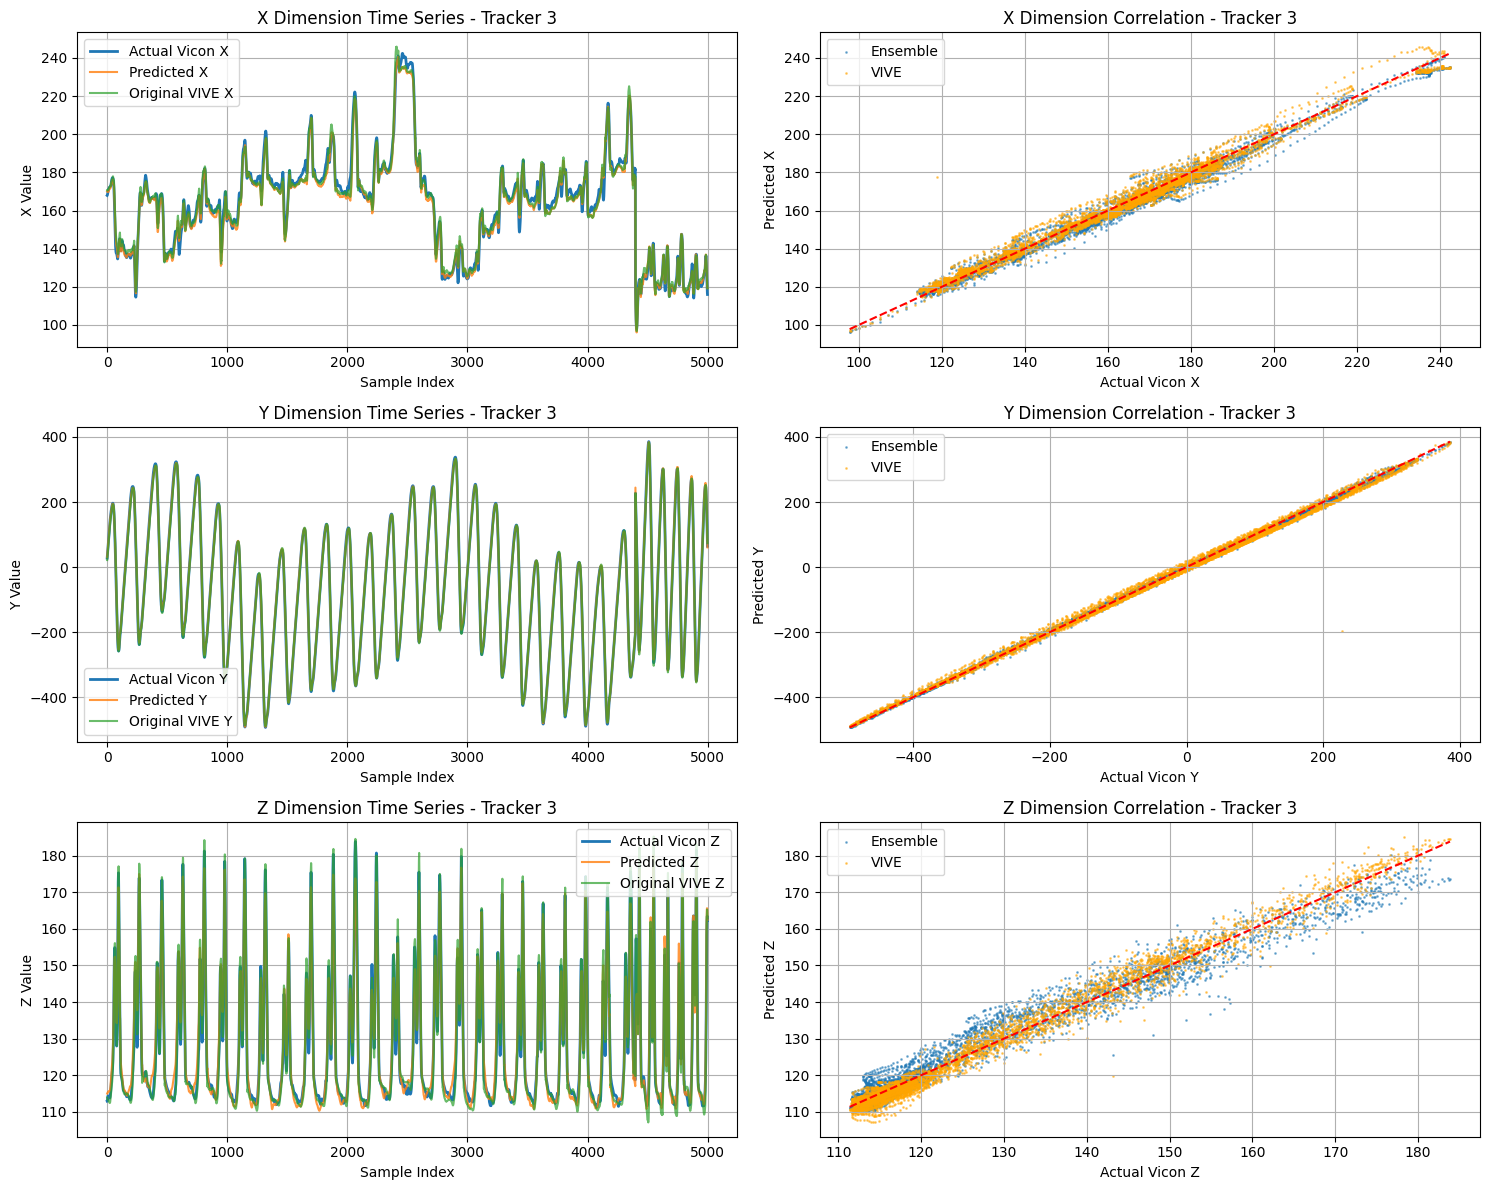

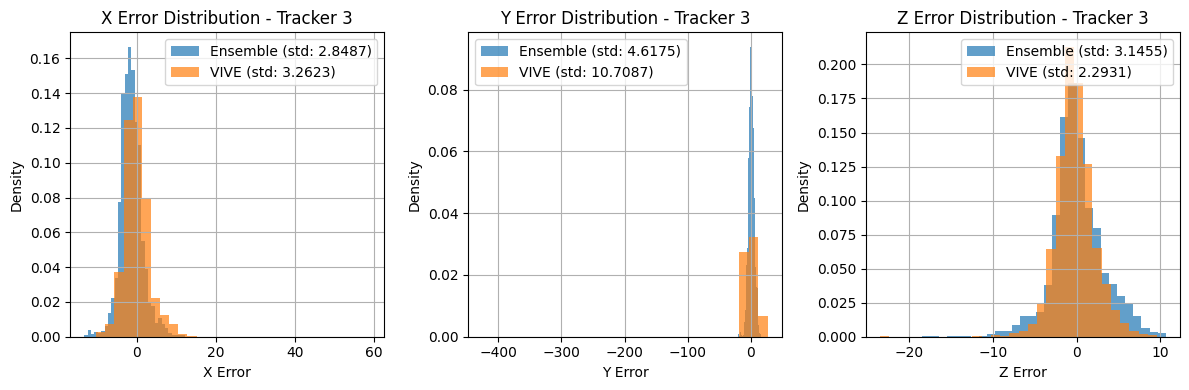


Per-Dimension Statistics:
X Dimension:
  VIVE RMSE:     3.2624
  Ensemble RMSE: 3.1507
  Improvement:   +3.42%
Y Dimension:
  VIVE RMSE:     10.7130
  Ensemble RMSE: 4.6871
  Improvement:   +56.25%
Z Dimension:
  VIVE RMSE:     2.2993
  Ensemble RMSE: 3.1483
  Improvement:   -36.93%


In [18]:
def load_ensemble_models():
    with open('feet_ensemble_models_LOPO.pkl', 'rb') as f:
        ensemble_data = pickle.load(f)
    return ensemble_data

# Integrated prediction function
def ensemble_predict_custom(start_index, length, X_time, X_feat, y, tracker_info=None):
    """
    Make predictions using the ensemble model on a subset of data.

    Parameters:
    -----------
    start_index : int
        Starting index for the prediction subset
    length : int
        Number of samples to predict
    X_time : ndarray
        RAW time series features (unscaled)
    X_feat : ndarray
        RAW additional features (unscaled): [speed, tracker_height, vive_spatial_mag]
    y : ndarray
        RAW ground truth targets (unscaled)
    tracker_info : int, optional
        Tracker ID to filter data (1, 2, or 3). If None, uses all data.

    Returns:
    --------
    predictions_original : ndarray
        Ensemble predictions in original scale
    y_original : ndarray
        Ground truth in original scale
    vive_original : ndarray
        Original VIVE data in original scale
    """
    # Load ensemble model data
    ensemble_data = load_ensemble_models()
    model_states = ensemble_data['model_states']
    fold_scalers = ensemble_data['preprocessing']['scalers']  # per-fold scalers

    # Filter data by tracker if specified
    if tracker_info is not None:
        # Tracker height is column index 1 in X_feat ([speed, height, spatial]).
        # X_feat is RAW now, so no inverse transform is needed.
        height_rounded = np.round(X_feat[:, 1]).astype(int)

        # Filter indices for the specified tracker
        tracker_mask = (height_rounded == tracker_info)
        tracker_indices = np.where(tracker_mask)[0]

        print(f"Filtering data for Tracker {tracker_info}...")
        print(f"Unique values (after rounding): {np.unique(height_rounded)}")

        if len(tracker_indices) == 0:
            print(f"Error: No data found for Tracker {tracker_info}")
            print(f"Available Tracker values: {np.unique(height_rounded)}")
            return None

        # Use filtered data
        X_time = X_time[tracker_mask]
        X_feat = X_feat[tracker_mask]
        y = y[tracker_mask]

        print(f"Successfully filtered Tracker {tracker_info} data: {len(X_time)} samples")

    # Validate index range
    end_index = min(start_index + length, len(X_time))
    if start_index >= len(X_time) or start_index < 0:
        print(f"Error: Start index out of range [0, {len(X_time)-1}]")
        return None

    # Extract data subset (RAW values)
    X_time_subset = X_time[start_index:end_index]
    X_feat_subset = X_feat[start_index:end_index]
    y_subset = y[start_index:end_index]

    # Make predictions using all models in the ensemble.
    # Each model is scaled with its OWN fold scaler, and predictions are
    # inverse-transformed back to original units before averaging.
    all_predictions = []

    for model_state, scl in zip(model_states, fold_scalers):
        # Scale inputs with this fold's scaler
        n, sl, ch = X_time_subset.shape
        X_time_s = scl['vive_xyz'].transform(
            X_time_subset.reshape(-1, ch)).reshape(n, sl, ch)
        X_feat_s = scl['feat'].transform(X_feat_subset)

        test_dataset = TensorDataset(
            torch.tensor(X_time_s, dtype=torch.float32),
            torch.tensor(X_feat_s, dtype=torch.float32)
        )
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

        model = AdvancedTransformerModel(
            ensemble_data['model_config']['seq_length'],
            num_features=ensemble_data['model_config']['num_features']
        ).to(device)
        model.load_state_dict(model_state)
        model.eval()

        fold_preds = []
        with torch.no_grad():
            for batch_X_time, batch_X_feat in test_loader:
                batch_X_time = batch_X_time.to(device)
                batch_X_feat = batch_X_feat.to(device)
                output = model(batch_X_time, batch_X_feat)
                fold_preds.append(output.cpu().numpy())

        fold_preds = np.vstack(fold_preds)
        # Inverse-transform this fold's predictions to original units
        fold_preds = scl['vicon_xyz'].inverse_transform(fold_preds)
        all_predictions.append(fold_preds)

    # Average predictions across all models (in original units)
    predictions_original = np.mean(all_predictions, axis=0)

    # y_subset and X_time_subset are RAW (already in original units)
    y_original = y_subset
    vive_original = X_time_subset[:, -1]

    # Calculate evaluation metrics
    ensemble_mse = np.mean((predictions_original - y_original) ** 2)
    ensemble_rmse = np.sqrt(ensemble_mse)
    ensemble_mae = np.mean(np.abs(predictions_original - y_original))

    vive_mse = np.mean((vive_original - y_original) ** 2)
    vive_rmse = np.sqrt(vive_mse)
    vive_mae = np.mean(np.abs(vive_original - y_original))

    rmse_improvement = ((vive_rmse - ensemble_rmse) / vive_rmse) * 100
    mae_improvement = ((vive_mae - ensemble_mae) / vive_mae) * 100

    # Add tracker information to output
    tracker_label = f" (Tracker {tracker_info})" if tracker_info is not None else ""
    print(f"\nPrediction results for index range {start_index}-{end_index-1}{tracker_label}:")
    print(f"Original VIVE vs Vicon: RMSE={vive_rmse:.4f}, MAE={vive_mae:.4f}")
    print(f"Ensemble model vs Vicon: RMSE={ensemble_rmse:.4f}, MAE={ensemble_mae:.4f}")
    print(f"Improvement: RMSE {rmse_improvement:+.2f}%, MAE {mae_improvement:+.2f}%")

    # Visualization - Updated for 3D XYZ data
    sample_size = min(5000, len(predictions_original))

    # Add tracker information to plot titles
    title_suffix = f" - Tracker {tracker_info}" if tracker_info is not None else ""

    plt.figure(figsize=(15, 12))

    # Plot each XYZ dimension separately
    for i, dim in enumerate(['X', 'Y', 'Z']):
        plt.subplot(3, 2, i*2+1)
        plt.plot(y_original[:sample_size, i], label=f'Actual Vicon {dim}', linewidth=2)
        plt.plot(predictions_original[:sample_size, i], label=f'Predicted {dim}', alpha=0.8)
        plt.plot(vive_original[:sample_size, i], label=f'Original VIVE {dim}', alpha=0.7)
        plt.xlabel('Sample Index')
        plt.ylabel(f'{dim} Value')
        plt.title(f'{dim} Dimension Time Series{title_suffix}')
        plt.legend()
        plt.grid(True)

        plt.subplot(3, 2, i*2+2)
        plt.scatter(y_original[:sample_size, i], predictions_original[:sample_size, i],
                   alpha=0.5, s=1, label='Ensemble')
        plt.scatter(y_original[:sample_size, i], vive_original[:sample_size, i],
                   alpha=0.5, s=1, color='orange', label='VIVE')
        plt.plot([y_original[:sample_size, i].min(), y_original[:sample_size, i].max()],
                [y_original[:sample_size, i].min(), y_original[:sample_size, i].max()], 'r--')
        plt.xlabel(f'Actual Vicon {dim}')
        plt.ylabel(f'Predicted {dim}')
        plt.title(f'{dim} Dimension Correlation{title_suffix}')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Overall error distribution
    plt.figure(figsize=(12, 4))

    for i, dim in enumerate(['X', 'Y', 'Z']):
        plt.subplot(1, 3, i+1)
        ensemble_errors = predictions_original[:, i] - y_original[:, i]
        vive_errors = vive_original[:, i] - y_original[:, i]

        plt.hist(ensemble_errors, bins=30, alpha=0.7,
                label=f'Ensemble (std: {np.std(ensemble_errors):.4f})', density=True)
        plt.hist(vive_errors, bins=30, alpha=0.7,
                label=f'VIVE (std: {np.std(vive_errors):.4f})', density=True)
        plt.xlabel(f'{dim} Error')
        plt.ylabel('Density')
        plt.title(f'{dim} Error Distribution{title_suffix}')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Print per-dimension statistics
    print(f"\nPer-Dimension Statistics:")
    print(f"{'='*40}")
    for i, dim in enumerate(['X', 'Y', 'Z']):
        ensemble_rmse_dim = np.sqrt(np.mean((predictions_original[:, i] - y_original[:, i]) ** 2))
        vive_rmse_dim = np.sqrt(np.mean((vive_original[:, i] - y_original[:, i]) ** 2))
        improvement_dim = ((vive_rmse_dim - ensemble_rmse_dim) / vive_rmse_dim) * 100

        print(f"{dim} Dimension:")
        print(f"  VIVE RMSE:     {vive_rmse_dim:.4f}")
        print(f"  Ensemble RMSE: {ensemble_rmse_dim:.4f}")
        print(f"  Improvement:   {improvement_dim:+.2f}%")

    return predictions_original, y_original, vive_original

# Test the prediction function
predictions, actual, vive = ensemble_predict_custom(
    start_index=40001,
    length=5000,
    X_time=X_time,
    X_feat=X_feat,
    y=y,
    tracker_info=3  # Tracker: 1, 2, or 3
)